# ***Ⅱ. 텍스트 데이터 처리***

## ***2. 텍스트 자료의 정보추출***
- 텍스트로부터 유용한 정보를 추출하는 방법에 대해 알아봅니다
- 단어 빈도수: 지난주까지 진행한 내용입니다
- 이번주에는 아래 내용을 중심으로 알아봅니다
    - 문서 빈도수
    - 상대 도수
    - 역문서 빈도수
    - TF-IDF

### ***단어 빈도수 (Term Frequency, TF)***
- 특정 단어가 문서 안에서 몇 번 등장했는지 세어 벡터로 표현
- 예: 음식 리뷰 8개에서 음식별 언급 횟수

$
\vec{v} = \sum_{i=1}^{8} \text{review}_i = (4, 8, 3, 5, 0)
$

### ***문서 빈도수 (Document Frequency, DF)***
- 단어가 몇 개 문서에 등장했는지 세는 값
$
DF(\text{짜장면}) = 4
$


### ***상대 도수 (DF/N, Relative Frequency)***
- 어떤 범주(단어, 음식, 감정 등)가 전체에서 차지하는 비율
$
\vec{v}_{rel} = \frac{\vec{v}}{\sum \vec{v}} = \left(\frac{4}{20}, \frac{8}{20}, \frac{3}{20}, \frac{5}{20}, \frac{0}{20}\right) = (0.2, 0.4, 0.15, 0.25, 0)
$


### ***역문서 빈도수 (Inverse Document Frequency, IDF)***
- 흔한 단어를 무시하고, 희귀 단어를 강조
$
IDF(t) = \log\frac{N}{DF(t)}
$
        N : 전체 문서 수, DF(t) : 단어 t가 등장한 문서 수

### ***TF-IDF(TF x IDF)***
- 흔한 단어를 무시하고, 희귀 단어를 강조
$
TF\text{-}IDF(t,d) = TF(t,d) \times IDF(t)
$

## ***문서 빈도수 벡터***

- **문서 빈도수(DF):** 특정 단어(음식)가 등장한 **문서(리뷰)의 수**  
- 음식 리뷰 8개를 기준으로 DF를 계산합니다.

### ***리뷰 예시***
```plaintext
리뷰 1: "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요"
리뷰 2: "짬뽕이 최고였어요"
리뷰 3: "짜장면도 좋고 짬뽕도 맛있었어요"
리뷰 4: "짬뽕이 맛있고 탕수육도 괜찮았어요"
리뷰 5: "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요"
리뷰 6: "짜장면, 짬뽕, 볶음밥, 탕수육 다 맛있었어요"
리뷰 7: "짬뽕과 탕수육 먹었어요"
리뷰 8: "짬뽕이 맛있고 볶음밥, 탕수육도 괜찮았어요"
```

### ***문서 빈도수 계산***
- 짜장면: 리뷰 1, 3, 5, 6 → 4개 문서  
- 짬뽕: 리뷰 1, 2, 3, 4, 5, 6, 7, 8 → 8개 문서  
- 볶음밥: 리뷰 1, 6, 8 → 3개 문서  
- 탕수육: 리뷰 1, 4, 5, 6, 7, 8 → 6개 문서  
- 양장피: 등장 없음 → 0개 문서  

$
DF = (4, 8, 3, 6, 0)
$

---

### ***해석***
- 문서 빈도수는 **단순히 등장한 리뷰의 수**를 나타냅니다.  
- 상대도수와 달리 **횟수 무시, 등장 여부만 고려**  
- 이후 TF-IDF 계산에 사용됩니다.

$
DF(\text{짜장면}) = 4, \quad
DF(\text{짬뽕}) = 8, \quad
DF(\text{볶음밥}) = 3, \quad
DF(\text{탕수육}) = 6, \quad
DF(\text{양장피}) = 0
$

In [2]:
! sudo apt-get install fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (25.5 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direct

문서 빈도수 벡터 (DF): [4 8 3 6 0 8]


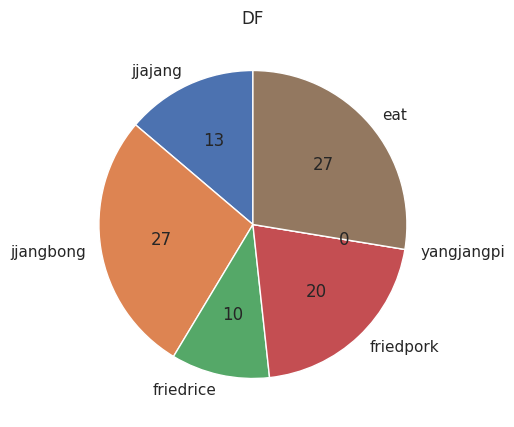

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import re

# 폰트 설정 (Colab, Ubuntu 기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')

# 리뷰 8개
reviews = [
    "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요",
    "짬뽕 먹었는데 최고였어요",
    "짜장면도 좋고 짬뽕도 먹었는데 맛있었어요",
    "짬뽕이 맛있고 탕수육도 먹었는데 괜찮았어요",
    "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요",
    "짜장면, 짬뽕, 볶음밥, 탕수육 다 먹었는데 맛있었어요",
    "짬뽕과 탕수육 먹었어요",
    "짬뽕이 맛있고 볶음밥, 탕수육도 먹었는데 괜찮았어요"
]

# 음식 종류 (단어 가방)
foods = ["짜장면", "짬뽕", "볶음밥", "탕수육", "양장피", "먹었"]

def document_frequency(reviews, foods):
    df = []
    for food in foods:
        count = sum(1 if re.search(food, review) else 0 for review in reviews)
        df.append(count)
    return np.array(df)

DF = document_frequency(reviews, foods)
print("문서 빈도수 벡터 (DF):", DF)
plt.figure(figsize=(5,5))

labels = ['jjajang', 'jjangbong', 'friedrice', 'friedpork', 'yangjangpi', "eat"]

# 백분율로 환산
plt.pie(DF, labels=labels, autopct="%d", startangle=90)

# 원래 값 그대로
# plt.pie(DF, labels=foods, autopct=lambda p: int(round(p*sum(DF)/100)), startangle=90)
plt.title("DF")
plt.show()

## ***상대도수 벡터***
음식 리뷰 벡터화로 알아봅니다

### ***리뷰 벡터화***
- 음식 종류: **짜장면, 짬뽕, 볶음밥, 탕수육, 양장피**
```plaintext
    "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요",
    "짬뽕이 최고였어요",
    "짜장면도 좋고 짬뽕도 맛있었어요",
    "짬뽕이 맛있고 탕수육도 괜찮았어요",
    "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요",
    "짜장면, 짬뽕, 볶음밥, 탕수육 다 맛있었어요",
    "짬뽕과 탕수육 먹었어요",
    "짬뽕이 맛있고 볶음밥, 탕수육도 괜찮았어요"
```
- 각 리뷰를 5차원 벡터로 표현 (각 성분 = 언급 횟수)

$
\text{리뷰 1} = (1, 1, 1, 0, 0),\quad
\text{리뷰 2} = (0, 1, 0, 0, 0),\quad
\dots
$

---

### ***벡터 합***
- 8개 리뷰 벡터를 더하면 전체 언급 횟수 벡터:

$
\begin{aligned}
&(1, 1, 1, 0, 0) + (0, 1, 0, 0, 0) + (1, 1, 0, 0, 0) + (0, 1, 0, 1, 0) \\
&+ (1, 1, 0, 1, 0) + (1, 1, 1, 1, 0) + (0, 1, 0, 1, 0) + (0, 1, 1, 1, 0) \\
&= (4, 8, 3, 5, 0)
\end{aligned}
$

---

### ***상대도수 벡터***
- 총 언급 수: \(4 + 8 + 3 + 5 + 0 = 20\)
- 상대도수:

$
(0.2, 0.4, 0.15, 0.25, 0)
$

- 짬뽕 상대도수 0.4 → 언급된 음식 중 **40%가 짬뽕**

---

In [10]:
# 한글 폰트 및 시각화 라이브러리 설치
! sudo apt install -y fonts-nanum
! pip install seaborn

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [11]:
import re
import numpy as np

# 예시: 음식 리뷰 8개
review_texts = [
    "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요",
    "짬뽕이 최고였어요",
    "짜장면도 좋고 짬뽕도 맛있었어요",
    "짬뽕이 맛있고 탕수육도 괜찮았어요",
    "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요",
    "짜장면, 짬뽕, 볶음밥, 탕수육 다 맛있었어요",
    "짬뽕과 탕수육 먹었어요",
    "짬뽕이 맛있고 볶음밥, 탕수육도 괜찮았어요"
]

# 각 음식별 키워드 패턴
food_patterns = {
    '짜장면': r'짜장면',
    '짬뽕': r'짬뽕',
    '볶음밥': r'볶음밥',
    '탕수육': r'탕수육',
    '양장피': r'양장피'
}

def review_to_vector(review, patterns):
    vector = [len(re.findall(p, review)) for p in patterns.values()]
    return vector

# 모든 리뷰를 벡터로 변환
reviews = np.array([review_to_vector(r, food_patterns) for r in review_texts])
print(reviews)

[[1 1 1 1 0]
 [0 1 0 0 0]
 [1 1 0 0 0]
 [0 1 0 1 0]
 [1 1 0 1 0]
 [1 1 1 1 0]
 [0 1 0 1 0]
 [0 1 1 1 0]]


총 언급 횟수 벡터: [4 8 3 6 0]
상대도수 벡터: [0.19047619 0.38095238 0.14285714 0.28571429 0.        ]


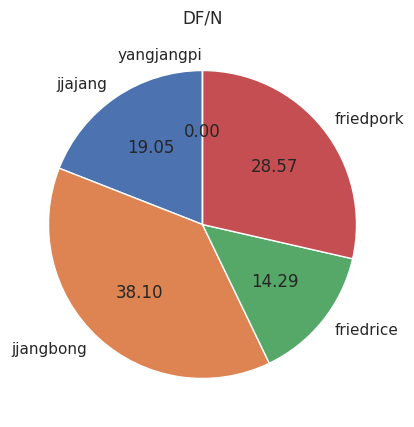

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib
matplotlib.set_loglevel("error")  # warning 이상은 무시

# 폰트 설정 (Colab, Ubuntu 기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')

# 총 언급 횟수 벡터
total_vector = reviews.sum(axis=0)
print("총 언급 횟수 벡터:", total_vector)

# 상대도수 벡터
DF_over_N = total_vector / total_vector.sum()
print("상대도수 벡터:", DF_over_N)

# 시각화 (파이 차트, 한글폰트 깨짐방지)
# labels = ['짜장면', '짬뽕', '볶음밥', '탕수육', '양장피']
labels = ['jjajang', 'jjangbong', 'friedrice', 'friedpork', 'yangjangpi']

plt.figure(figsize=(5,5))
plt.pie(DF_over_N, labels=labels, autopct="%.2f", startangle=90)
plt.title("DF/N")
plt.show()

### ***역문서 빈도수 (Inverse Document Frequency, IDF)***

- 특정 단어가 얼마나 희귀한지를 나타내는 지표
- 자주 등장하는 단어는 중요도가 낮고, 드물게 등장하는 단어는 중요도가 높다고 판단

    $
    IDF(t) = \log \frac{N}{DF(t)}
    $

- $(N)$ : 전체 문서 수
- $(DF(t))$ : 단어 $(t)$가 등장한 문서 수

**예시**:  
- 전체 리뷰 수 \(N = 8\)  
- 짬뽕 등장한 문서 수 $(DF(\text{짬뽕}) = 7)$

    $
    IDF(\text{짬뽕}) = \log \frac{8}{7} \approx 0.1335
    $

- 드물게 등장한 음식일수록 IDF 값이 커져 중요도가 상승
```

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib
matplotlib.set_loglevel("error")  # warning 이상은 무시

# 폰트 설정 (Colab, Ubuntu 기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')


# 문서 8개, 단어 5개 (짜장면, 짬뽕, 볶음밥, 탕수육, 양장피)
review_vectors = np.array([
    [1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 1, 0, 1, 0],
    [1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0]
])

# 전체 문서 수
N = review_vectors.shape[0]

# 단어별 문서 등장 수
DF = np.count_nonzero(review_vectors, axis=0)

# 역문서 빈도수
IDF = np.log(N / DF)

print("단어별 문서 등장 수 DF:", DF)
print("단어별 역문서 빈도수 IDF:", IDF)

단어별 문서 등장 수 DF: [4 8 3 6 0]
단어별 역문서 빈도수 IDF: [0.69314718 0.         0.98082925 0.28768207        inf]


/tmp/ipykernel_4072/828823726.py:35: RuntimeWarning: divide by zero encountered in divide
  IDF = np.log(N / DF)


### ***Zero division 방지***
- 스무딩 적용 버전:

    $
    IDF(t) = \log \frac{N}{1 + DF(t)} + 1
    $

- $N$ : 전체 문서 수  
- $DF(t)$ : 단어 $t$가 등장한 문서 수  

- 설명:  
    - $DF(t) = 0$일 때 0으로 나누는 것을 방지  
    - IDF가 0이 되는 것을 방지하기 위해 마지막 +1 추가 가능  
    - 전체 문서 수 $N$에는 +1 하지 않음 (전체 문서 수를 그대로 사용)

단어별 문서 등장 수 DF: [4 8 3 6 0]
스무딩 적용한 IDF: [1.47000363 0.88221696 1.69314718 1.13353139 3.07944154]


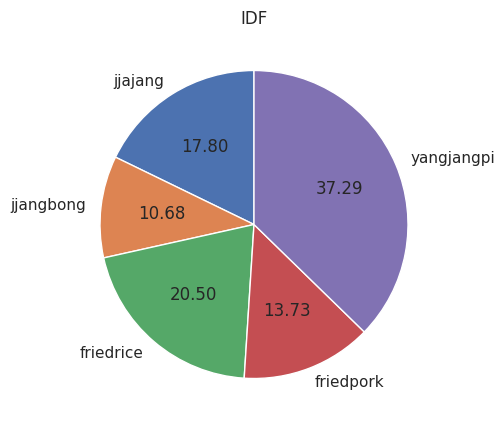

In [18]:
# 역문서 빈도수
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 폰트 설정 (Colab, Ubuntu 기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')


# 문서 8개, 단어 5개 (짜장면, 짬뽕, 볶음밥, 탕수육, 양장피)
review_vectors = np.array([
    [1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 1, 0, 1, 0],
    [1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0]
])


# 전체 문서 수
N = review_vectors.shape[0]

# 단어별 문서 등장 수
DF = np.count_nonzero(review_vectors, axis=0)
# 시각화 (파이 차트, 한글폰트 깨짐방지)
# labels = ['짜장면', '짬뽕', '볶음밥', '탕수육', '양장피']
labels = ['jjajang', 'jjangbong', 'friedrice', 'friedpork', 'yangjangpi']


# 역문서 빈도수
# IDF 스무딩 적용
IDF_smooth = np.log(N / (1 + DF)) + 1
print("단어별 문서 등장 수 DF:", DF)
print("스무딩 적용한 IDF:", IDF_smooth)

plt.figure(figsize=(5,5))
plt.pie(IDF_smooth, labels=labels, autopct="%.2f", startangle=90)
plt.title("IDF")
plt.show()

### ***TF-IDF (Term Frequency - Inverse Document Frequency)***
- TF-IDF 수식:

    $
    TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)
    $

- $TF(t, d)$ : 문서 $d$에서 단어 $t$의 등장 횟수  
- $IDF(t)$ : 역문서 빈도수, 단어 $t$가 전체 문서에서 얼마나 드문지 나타냄  

- 설명:  
    - TF는 문서 내에서 단어가 얼마나 자주 나오는지를 나타냄  
    - IDF는 전체 문서에서 단어가 얼마나 희귀한지를 나타냄  
    - TF와 IDF를 곱하면, 특정 문서에서 중요한 단어일수록 값이 커짐

TF (Term Frequency):
 [[1. 1. 1. 1. 0.]
 [0. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 1. 0. 1. 0.]
 [1. 1. 0. 1. 0.]
 [1. 1. 1. 1. 0.]
 [0. 1. 0. 1. 0.]
 [0. 1. 1. 1. 0.]]

DF (Document Frequency):
 [4 8 3 6 0]

IDF (Inverse Document Frequency):
 [1.58778666 1.         1.81093022 1.25131443 3.19722458]

TF-IDF:
 [[1.58778666 1.         1.81093022 1.25131443 0.        ]
 [0.         1.         0.         0.         0.        ]
 [1.58778666 1.         0.         0.         0.        ]
 [0.         1.         0.         1.25131443 0.        ]
 [1.58778666 1.         0.         1.25131443 0.        ]
 [1.58778666 1.         1.81093022 1.25131443 0.        ]
 [0.         1.         0.         1.25131443 0.        ]
 [0.         1.         1.81093022 1.25131443 0.        ]]


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51692 (\N{HANGUL SYLLABLE JJAM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48981 (\N{HANGUL SYLLABLE BBONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48374 (\N{HANGUL SYLLABLE BOGG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw

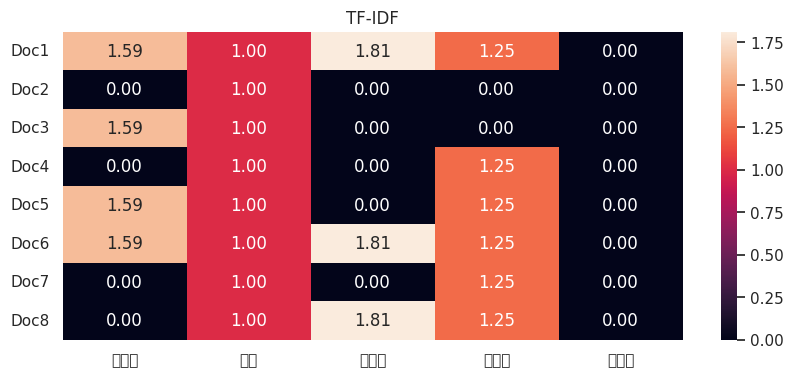

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 폰트 설정 (Colab, Ubuntu 기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')

# 리뷰 예제
documents = [
    "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요",
    "짬뽕이 최고였어요",
    "짜장면도 좋고 짬뽕도 맛있었어요",
    "짬뽕이 맛있고 탕수육도 괜찮았어요",
    "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요",
    "짜장면, 짬뽕, 볶음밥, 탕수육 다 맛있었어요",
    "짬뽕과 탕수육 먹었어요",
    "짬뽕이 맛있고 볶음밥, 탕수육도 괜찮았어요"
]

# 단어 목록
labels = ["짜장면", "짬뽕", "볶음밥", "탕수육", "양장피"]

# TF 계산 (문서별 단어 등장 횟수)
TF = np.zeros((len(documents), len(labels)))
for i, doc in enumerate(documents):
    for j, w in enumerate(labels):
        TF[i, j] = doc.count(w)

# DF 계산 (문서 빈도수)
DF = np.sum(TF > 0, axis=0)

# IDF 계산 (역문서 빈도수, +1 smoothing)
N = len(documents)
IDF = np.log((N + 1) / (DF + 1)) + 1  # 스무딩

# TF-IDF 계산
TF_IDF = TF * IDF

print("TF (Term Frequency):\n", TF)
print("\nDF (Document Frequency):\n", DF)
print("\nIDF (Inverse Document Frequency):\n", IDF)
print("\nTF-IDF:\n", TF_IDF)

plt.figure(figsize=(10,4))
sns.heatmap(TF_IDF, annot=True, fmt=".2f", xticklabels=labels, yticklabels=[f'Doc{i+1}' for i in range(TF_IDF.shape[0])])
plt.title("TF-IDF")
plt.show()

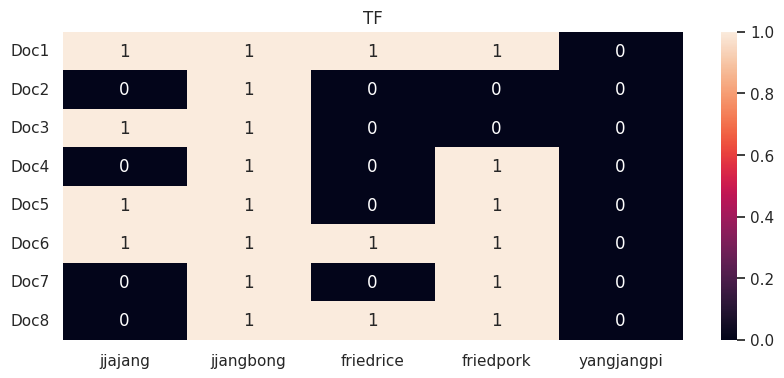

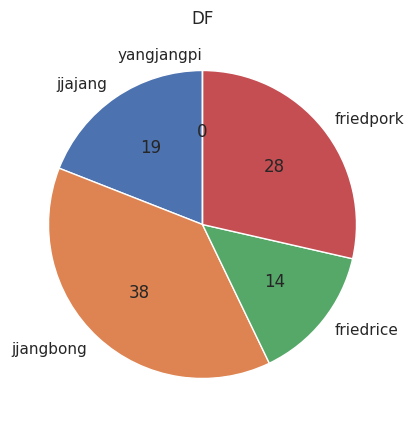

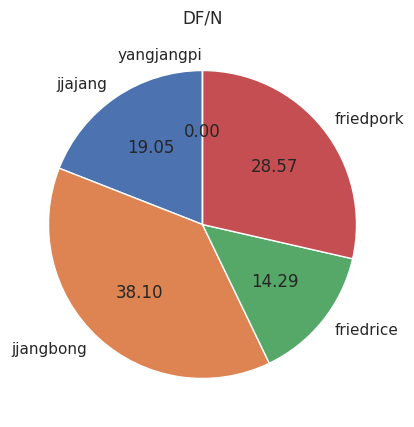

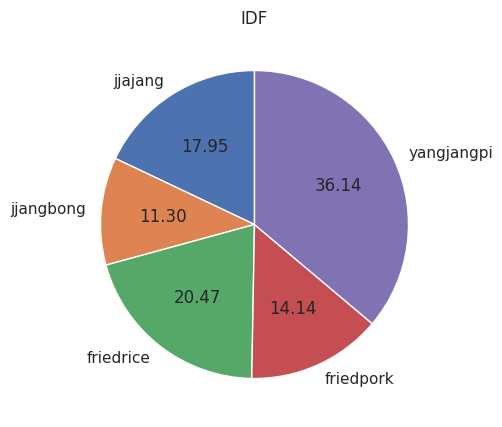

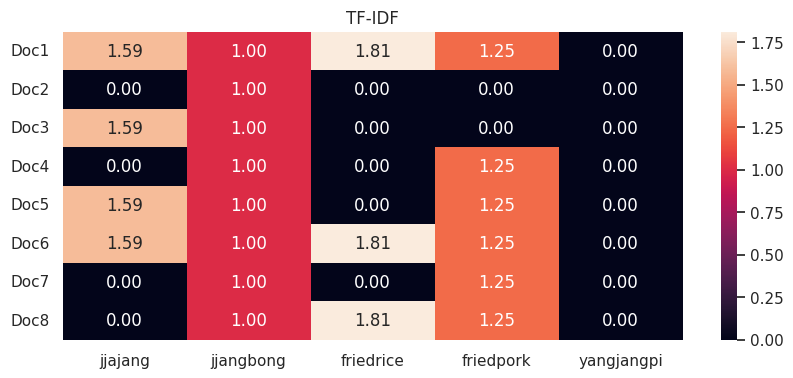

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 폰트 설정 (Colab기준)
nanum_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
nanum_font = fm.FontProperties(fname=nanum_font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.rc("font", family="NanumGothic")
sns.set_theme(font="NanumGothic", rc={"axes.unicode_minus":False}, style='white')

# 예제 문서 5개, 단어 5개
review_texts = [
    "짜장면 먹었는데 짬뽕도 좋았어요, 볶음밥은 그저 그랬고 탕수육은 괜찮아요",
    "짬뽕이 최고였어요",
    "짜장면도 좋고 짬뽕도 맛있었어요",
    "짬뽕이 맛있고 탕수육도 괜찮았어요",
    "짜장면 먹고 짬뽕도 먹었어요, 탕수육도 괜찮아요",
    "짜장면, 짬뽕, 볶음밥, 탕수육 다 맛있었어요",
    "짬뽕과 탕수육 먹었어요", # 수정: 짬뽕과 탕수육하고 양장피도 먹었어요
    "짬뽕이 맛있고 볶음밥, 탕수육도 괜찮았어요"
]
labels = ["짜장면","짬뽕","볶음밥","탕수육","양장피"]

food_patterns = {
    '짜장면': r'짜장면',
    '짬뽕': r'짬뽕',
    '볶음밥': r'볶음밥',
    '탕수육': r'탕수육',
    '양장피': r'양장피'
}

def review_to_vector(review, patterns):
    vector = [len(re.findall(p, review)) for p in patterns.values()]
    return vector

# 모든 리뷰를 벡터로 변환
review_vectors = np.array([review_to_vector(r, food_patterns) for r in review_texts])

# TF 계산
TF = np.zeros((len(documents), len(labels)))
for i, doc in enumerate(documents):
    for j, w in enumerate(labels):
        TF[i, j] = doc.count(w)

# DF 계산 (단어별 등장 문서 수)
DF = np.count_nonzero(TF, axis=0)

# 상대문서빈도 DF/N
N = len(documents)
DF_over_N = DF / N

# IDF 계산 (smoothed)
IDF = np.log((N+1)/(DF+1)) + 1

# TF-IDF 계산
TF_IDF = TF * IDF

# 시각화 (파이 차트, 한글폰트 깨짐방지)
# labels = ['짜장면', '짬뽕', '볶음밥', '탕수육', '양장피']
labels = ['jjajang', 'jjangbong', 'friedrice', 'friedpork', 'yangjangpi']

# 1. TF 히트맵
plt.figure(figsize=(10,4))
sns.heatmap(TF.astype(int), annot=True, fmt="d", xticklabels=labels, yticklabels=[f'Doc{i+1}' for i in range(TF.shape[0])])
plt.title("TF")
plt.show()

# 2. DF 파이차트
plt.figure(figsize=(5,5))
plt.pie(DF, labels=labels, autopct="%d", startangle=90)
plt.title("DF")
plt.show()

# 3. DF/N 파이차트
plt.figure(figsize=(5,5))
plt.pie(DF_over_N, labels=labels, autopct="%.2f", startangle=90)
plt.title("DF/N")
plt.show()

# 4. IDF 파이차트
plt.figure(figsize=(5,5))
plt.pie(IDF, labels=labels, autopct="%.2f", startangle=90)
plt.title("IDF")
plt.show()

# 5. TF-IDF 히트맵
plt.figure(figsize=(10,4))
sns.heatmap(TF_IDF, annot=True, fmt=".2f", xticklabels=labels, yticklabels=[f'Doc{i+1}' for i in range(TF_IDF.shape[0])])
plt.title("TF-IDF")
plt.show()

## ***TF-IDF를 이용하여 텍스트 데이터 분석하기***
- 교과서에 소개된 Askmath AI 웹실험실과 샘플 텍스트를 이용하여 미세먼저와 관련된 기사 제목 10개를 문서 입력 합니다
- 텍스트 전처리 과정을 확인합니다
- 우리도 텍스트 전처리 과정을 진행해봅니다

In [ ]:
! pip install konlpy

In [ ]:
import re
from konlpy.tag import Okt

# 1. 원본 문장
sentence = "미세먼지 농도 급증, 대기오염 주의보 발령."

# 2. 숫자 및 문장 부호 제거
clean_sentence = re.sub(r"[^가-힣\s]", "", sentence)
print("숫자 및 문장 부호 제거:", clean_sentence)

# 3. 토큰화 및 어간 추출
okt = Okt()
tokens = okt.morphs(clean_sentence, stem=True)  # stem=True -> 어간 추출
print("토큰화 + 어간 추출:", tokens)

# 4. 불용어 제거 (직접 찾아보고 수정해봅시다)
stopwords = {"의", "가", "이", "은", "들", "는", "좀", "잘", "과", "도", "를", "으로", "자", "에", "와", "한", "하다"}
tokens_no_stop = [t for t in tokens if t not in stopwords]
print("불용어 제거:", tokens_no_stop)

# 5. 명사 추출
nouns = okt.nouns(clean_sentence)
print("추출된 명사:", nouns)

## ***텍스트 시각화***
- 아래 예시에 있는 text를 위에서 전처리된 텍스트로 교체하여 시각화해봅니다

### ***빈도표***

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
import itertools
import matplotlib.font_manager as fm
import random
import logging
import matplotlib
import pandas as pd
matplotlib.set_loglevel("error")  # warning 이상은 무시

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fontprop = fm.FontProperties(fname=font_path)

text = """
짜장면 맛있다 짜장면 최고
짬뽕도 맛있다 짜장면도 좋다
탕수육 최고 짜장면 최고
짬뽕 별로 짜장면 맛있다
탕수육 맛있다
"""

# 문장 단위 분리
docs = [line.strip() for line in text.strip().split("\n")]

# -----------------------------
# 단어 빈도 계산
word_freq = Counter()
for doc in docs:
    word_freq.update(doc.split())

# 빈도표 출력
# pandas DataFrame으로 변환
df = pd.DataFrame(word_freq.items(), columns=['단어', '빈도']).sort_values(by='빈도', ascending=False)

# 테이블 출력
display(df)

### ***막대그래프***

In [ ]:
# 막대그래프
words = list(word_freq.keys())
freqs = list(word_freq.values())

plt.figure(figsize=(8,5))
plt.bar(words, freqs, color='skyblue')
plt.title("단어별 빈도", fontproperties=fontprop)
plt.xlabel("단어", fontproperties=fontprop)
plt.ylabel("빈도", fontproperties=fontprop)
plt.xticks(fontproperties=fontprop)
plt.show()

### ***워크 클라우드***

In [ ]:
! sudo apt update && sudo apt-get install -y fonts-nanum

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = """
짜장면 맛있다 짜장면 최고
짬뽕도 맛있다 짜장면도 좋다
탕수육 최고 짜장면 최고
짬뽕 별로 짜장면 맛있다
탕수육 맛있다
"""

wc = WordCloud(
    font_path="NanumGothic.ttf",  # 한글 폰트 필요
    background_color="white"
).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

### ***연결망***

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
import itertools
import matplotlib.font_manager as fm
import random

random.seed(42)

# 한글 폰트
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fontprop = fm.FontProperties(fname=font_path)

docs = [
    "짜장면 맛있다 짜장면 최고",
    "짬뽕도 맛있다 짜장면도 좋다",
    "탕수육 최고 짜장면 최고",
    "짬뽕 별로 짜장면 맛있다",
    "탕수육 맛있다"
]

# 1. 단어 co-occurrence
edges = Counter()
for doc in docs:
    words = list(set(doc.split()))
    for pair in itertools.combinations(words, 2):
        edges[pair] += 1

G = nx.Graph()
for (w1, w2), weight in edges.items():
    G.add_edge(w1, w2, weight=weight)

pos = nx.spring_layout(G, seed=42)
weights = [G[u][v]['weight'] for u,v in G.edges()]

# 2. 문장별 색상 생성
doc_colors = [ (random.random(), random.random(), random.random()) for _ in docs ]

# 3. 단어별 색상 매핑 (첫 등장 문장 기준)
word_colors = {}
for doc_idx, doc in enumerate(docs):
    for word in doc.split():
        if word not in word_colors:
            word_colors[word] = doc_colors[doc_idx]

# 4. 노드, 엣지 그리기
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=2000)
nx.draw_networkx_edges(G, pos, width=weights)

# 5. 라벨 그리기 (문장별 색상 적용)
for node, (x, y) in pos.items():
    plt.text(x, y, node, fontproperties=fontprop,
             horizontalalignment='center', verticalalignment='center',
             fontsize=12, color=word_colors[node])

plt.axis('off')
plt.show()